<b>COSMIC RADIATION: deep learning</b>
    
rodrigoX: Contains 4 parameters
    1. NALLParticlesTotal : Total number of particles generated by the event in the ground level.
    2. MUTotal : Total number of muons.
    3. ELTotal : Total number of electromagnetic particles.
    4. Zenith : Zenith angle of the particle [degrees].
    5. Energy : Particle energy [GeV].

rodrigoY: contains the target
    Labels: photon, proton, helium, nitrogen, iron.
        the smallest number is assigned to photon (A=0) and the highest number to the heaviest particle, this is, iron (B=4).
        
        0==photon     1==proton    2==helium     3==nitrogen   4==iron 
     

In [1]:
# # To Save a session
# import dill
# import pickle
# dill.dump_session('notebook_env.db') #esto es de la forma normal,solo de la otra forma no funciona con tensoflow
# with open('basic_history.pickle', 'wb') as f:
#     pickle.dump(history.history, f)

In [2]:
# # To restore a session
# with open('basic_history.pickle', 'rb') as f:
#     history = pickle.load(f)#para cargar una variable
    
#dill.load_session('basic_history.pickle')

In [3]:
#Load it back:
model = tf.keras.models.load_model('cosmic_radiation.model')
#to save the model
#model.save('cosmic_radiation.model')

In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot
import tensorflow as tf
from tensorflow import keras

In [2]:
from tensorflow.keras.layers import BatchNormalization

from keras.models import Sequential
from keras.layers import Dense
from keras.wrappers.scikit_learn import KerasClassifier
from keras.utils import np_utils
from keras.layers import Dropout

from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline


Using TensorFlow backend.


### Data

In [9]:
df_x1

,-5.7113135e-01,-5.8777811e-01,-5.7071906e-01,-2.2340966e+00,-6.4510991e-01
0,0.018986,0.580245,0.017869,0.266255,0.035753
1,-0.599266,-0.685489,-0.598701,0.566118,-0.692270
2,0.090619,0.852811,0.089077,1.064418,0.257590
3,3.294124,4.080454,3.290221,0.214429,2.614472
4,-0.555058,-0.571193,-0.554657,0.486392,0.695705
...,...,...,...,...,...
17990,-0.581969,-0.588129,-0.581568,0.982473,-0.648572
17991,-0.234798,0.065629,-0.235226,0.621484,-0.205019
17992,-0.612594,-0.714732,-0.611988,0.495251,-0.708812
17993,-0.424997,-0.316467,-0.424930,0.971843,-0.471412


In [25]:
df_y=pd.read_fwf('YRodrigo.txt')
df_x = pd.read_fwf('XRodrigo.txt')
df_x.columns = ["NALLParticlesTotal", "MUTotal", "ELTotal", "Zenith","Energy"]
df_y.columns = ["Particle"]

transpose=df_x.T
transpose_y=df_y.T #Transpose to put them together
df_tot = transpose.append(transpose_y)
df_tot=df_tot.T.sample(frac=1).reset_index(drop=True)#este el el df completo y barajado

df_y=df_tot[['Particle']]
df_x=df_tot[["NALLParticlesTotal", "MUTotal", "ELTotal", "Zenith","Energy"]]

In [26]:
#para hacer la prueba con nuevo dataset
#leave the dataset ready
df_x_test = pd.read_fwf('XTest.txt')
df_y_test=pd.read_fwf('YTest.txt')
# X_train=df_x.to_numpy()
X_test2=df_x_test.to_numpy()
# y_train=df_y.to_numpy()
y_test2=df_y_test.to_numpy()

In [32]:
#train-test split and reescale
from sklearn.model_selection import train_test_split
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
X_train, X_test, y_train, y_test = train_test_split(df_x, df_y, random_state=0,test_size = 0.25)
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
y_train_np=y_train.to_numpy()
y_test_np=y_test.to_numpy()

In [28]:
print(len(X_train[0]))
len(df_x.to_numpy()[0])

5


5

### Model 

In [17]:
from tensorflow.keras.layers import BatchNormalization
# from tensorflow.keras.layers import Dropout

model = tf.keras.models.Sequential()

hidden_layers=5
for i in range(hidden_layers):
       
        model.add(tf.keras.layers.Dense(150, kernel_initializer='glorot_uniform', activation=tf.nn.relu))
        # model.add(BatchNormalization())    use_bias=False,
        # model.add(tf.keras.layers.Dropout(0.0))

model.add(tf.keras.layers.Dense(5, activation=tf.nn.softmax))

# N_TRAIN=X_train.shape[0];BATCH_SIZE=128
# STEPS_PER_EPOCH = N_TRAIN//BATCH_SIZE
# lr_schedule = tf.keras.optimizers.schedules.InverseTimeDecay( 0.001,decay_steps=STEPS_PER_EPOCH*500,decay_rate=1,staircase=False)
# #STEPS_PER_EPOCH*300-->The code above sets a schedules.InverseTimeDecay to hyperbolically decrease the learning rate to 1/2 of the base rate at 300 epochs, 1/3 at 600 epochs and so on.

optimizer = keras.optimizers.Adam(learning_rate=0.0001, beta_1=0.9, beta_2=0.999, amsgrad=False)

model.compile(optimizer=optimizer , loss='sparse_categorical_crossentropy',metrics=['accuracy'])
#If I want to know the weights of a layer:
#model.layers[1].get_weights()


In [18]:
%%time
history=model.fit(X_train, y_train_np, epochs=500, validation_data=(X_test, y_test))


Train on 13496 samples, validate on 4499 samples
Epoch 1/500
13496/13496 [==============================] - 2s 118us/sample - loss: 1.4118 - accuracy: 0.4266 - val_loss: 1.1245 - val_accuracy: 0.5739
Epoch 2/500
13496/13496 [==============================] - 1s 80us/sample - loss: 0.9734 - accuracy: 0.6389 - val_loss: 0.8483 - val_accuracy: 0.6990
Epoch 3/500
13496/13496 [==============================] - 1s 94us/sample - loss: 0.7817 - accuracy: 0.7222 - val_loss: 0.7607 - val_accuracy: 0.7248
Epoch 4/500
13496/13496 [==============================] - 1s 82us/sample - loss: 0.6754 - accuracy: 0.7659 - val_loss: 0.6271 - val_accuracy: 0.8051
Epoch 5/500
13496/13496 [==============================] - 1s 90us/sample - loss: 0.6029 - accuracy: 0.7996 - val_loss: 0.5974 - val_accuracy: 0.8073
Epoch 6/500
13496/13496 [==============================] - 1s 99us/sample - loss: 0.5507 - accuracy: 0.8195 - val_loss: 0.5216 - val_accuracy: 0.8193
Epoch 7/500
13496/13496 [=========================

Epoch 55/500
13496/13496 [==============================] - 2s 117us/sample - loss: 0.1779 - accuracy: 0.9273 - val_loss: 0.1938 - val_accuracy: 0.9133
Epoch 56/500
13496/13496 [==============================] - 1s 84us/sample - loss: 0.1886 - accuracy: 0.9248 - val_loss: 0.1587 - val_accuracy: 0.9480
Epoch 57/500
13496/13496 [==============================] - 1s 85us/sample - loss: 0.1886 - accuracy: 0.9246 - val_loss: 0.1619 - val_accuracy: 0.9475
Epoch 58/500
13496/13496 [==============================] - 1s 85us/sample - loss: 0.1749 - accuracy: 0.9321 - val_loss: 0.1636 - val_accuracy: 0.9353
Epoch 59/500
13496/13496 [==============================] - 1s 84us/sample - loss: 0.1897 - accuracy: 0.9253 - val_loss: 0.1594 - val_accuracy: 0.9418
Epoch 60/500
13496/13496 [==============================] - 1s 87us/sample - loss: 0.1727 - accuracy: 0.9306 - val_loss: 0.1549 - val_accuracy: 0.9544
Epoch 61/500
13496/13496 [==============================] - 1s 86us/sample - loss: 0.1825 - a

Epoch 163/500
13496/13496 [==============================] - 1s 82us/sample - loss: 0.1392 - accuracy: 0.9374 - val_loss: 0.1288 - val_accuracy: 0.9389
Epoch 164/500
13496/13496 [==============================] - 1s 83us/sample - loss: 0.1342 - accuracy: 0.9449 - val_loss: 0.1196 - val_accuracy: 0.9498
Epoch 165/500
13496/13496 [==============================] - 1s 82us/sample - loss: 0.1410 - accuracy: 0.9422 - val_loss: 0.1734 - val_accuracy: 0.9135
Epoch 166/500
13496/13496 [==============================] - 1s 81us/sample - loss: 0.1351 - accuracy: 0.9418 - val_loss: 0.1524 - val_accuracy: 0.9371
Epoch 167/500
13496/13496 [==============================] - 1s 82us/sample - loss: 0.1264 - accuracy: 0.9476 - val_loss: 0.1084 - val_accuracy: 0.9611
Epoch 168/500
13496/13496 [==============================] - 1s 82us/sample - loss: 0.1742 - accuracy: 0.9301 - val_loss: 0.1849 - val_accuracy: 0.9055
Epoch 169/500
13496/13496 [==============================] - 1s 85us/sample - loss: 0.12

Epoch 217/500
13496/13496 [==============================] - 1s 109us/sample - loss: 0.1081 - accuracy: 0.9534 - val_loss: 0.1362 - val_accuracy: 0.9335
Epoch 218/500
13496/13496 [==============================] - 1s 98us/sample - loss: 0.1202 - accuracy: 0.9460 - val_loss: 0.1091 - val_accuracy: 0.9578
Epoch 219/500
13496/13496 [==============================] - 2s 127us/sample - loss: 0.1279 - accuracy: 0.9454 - val_loss: 0.0980 - val_accuracy: 0.9691
Epoch 220/500
13496/13496 [==============================] - 1s 103us/sample - loss: 0.1118 - accuracy: 0.9495 - val_loss: 0.1721 - val_accuracy: 0.9186
Epoch 221/500
13496/13496 [==============================] - 1s 106us/sample - loss: 0.1168 - accuracy: 0.9492 - val_loss: 0.1510 - val_accuracy: 0.9338
Epoch 222/500
13496/13496 [==============================] - 2s 116us/sample - loss: 0.1378 - accuracy: 0.9433 - val_loss: 0.1224 - val_accuracy: 0.9407
Epoch 223/500
13496/13496 [==============================] - 1s 99us/sample - loss:

Epoch 271/500
13496/13496 [==============================] - 1s 85us/sample - loss: 0.1287 - accuracy: 0.9446 - val_loss: 0.0963 - val_accuracy: 0.9551
Epoch 272/500
13496/13496 [==============================] - 2s 111us/sample - loss: 0.1049 - accuracy: 0.9558 - val_loss: 0.0924 - val_accuracy: 0.9580
Epoch 273/500
13496/13496 [==============================] - 1s 110us/sample - loss: 0.1115 - accuracy: 0.9498 - val_loss: 0.1171 - val_accuracy: 0.9407
Epoch 274/500
13496/13496 [==============================] - 2s 132us/sample - loss: 0.1215 - accuracy: 0.9455 - val_loss: 0.0987 - val_accuracy: 0.9542
Epoch 275/500
13496/13496 [==============================] - 1s 111us/sample - loss: 0.1217 - accuracy: 0.9491 - val_loss: 0.0988 - val_accuracy: 0.9622
Epoch 276/500
13496/13496 [==============================] - 1s 90us/sample - loss: 0.1289 - accuracy: 0.9483 - val_loss: 0.0936 - val_accuracy: 0.9691
Epoch 277/500
13496/13496 [==============================] - 1s 83us/sample - loss: 

Epoch 325/500
13496/13496 [==============================] - 1s 105us/sample - loss: 0.1041 - accuracy: 0.9546 - val_loss: 0.1317 - val_accuracy: 0.9340
Epoch 326/500
13496/13496 [==============================] - 1s 107us/sample - loss: 0.1072 - accuracy: 0.9514 - val_loss: 0.0852 - val_accuracy: 0.9700
Epoch 327/500
13496/13496 [==============================] - 1s 103us/sample - loss: 0.1153 - accuracy: 0.9489 - val_loss: 0.1790 - val_accuracy: 0.9246
Epoch 328/500
13496/13496 [==============================] - 2s 121us/sample - loss: 0.0982 - accuracy: 0.9571 - val_loss: 0.1113 - val_accuracy: 0.9467
Epoch 329/500
13496/13496 [==============================] - 2s 116us/sample - loss: 0.1086 - accuracy: 0.9549 - val_loss: 0.0941 - val_accuracy: 0.9602
Epoch 330/500
13496/13496 [==============================] - 2s 124us/sample - loss: 0.1218 - accuracy: 0.9484 - val_loss: 0.1245 - val_accuracy: 0.9382
Epoch 331/500
13496/13496 [==============================] - 1s 107us/sample - los

Epoch 379/500
13496/13496 [==============================] - 1s 83us/sample - loss: 0.1158 - accuracy: 0.9504 - val_loss: 0.0915 - val_accuracy: 0.9631
Epoch 380/500
13496/13496 [==============================] - 1s 91us/sample - loss: 0.1107 - accuracy: 0.9536 - val_loss: 0.1069 - val_accuracy: 0.9484
Epoch 381/500
13496/13496 [==============================] - 1s 90us/sample - loss: 0.1127 - accuracy: 0.9510 - val_loss: 0.1611 - val_accuracy: 0.9246
Epoch 382/500
13496/13496 [==============================] - 1s 84us/sample - loss: 0.1039 - accuracy: 0.9547 - val_loss: 0.0908 - val_accuracy: 0.9620
Epoch 383/500
13496/13496 [==============================] - 1s 84us/sample - loss: 0.0972 - accuracy: 0.9575 - val_loss: 0.1351 - val_accuracy: 0.9329
Epoch 384/500
13496/13496 [==============================] - 1s 83us/sample - loss: 0.1123 - accuracy: 0.9511 - val_loss: 0.2070 - val_accuracy: 0.9155
Epoch 385/500
13496/13496 [==============================] - 1s 83us/sample - loss: 0.10

Epoch 433/500
13496/13496 [==============================] - 1s 89us/sample - loss: 0.1165 - accuracy: 0.9526 - val_loss: 0.1020 - val_accuracy: 0.9535
Epoch 434/500
13496/13496 [==============================] - 2s 118us/sample - loss: 0.1074 - accuracy: 0.9543 - val_loss: 0.0820 - val_accuracy: 0.9669
Epoch 435/500
13496/13496 [==============================] - 2s 118us/sample - loss: 0.0873 - accuracy: 0.9632 - val_loss: 0.0808 - val_accuracy: 0.9644
Epoch 436/500
13496/13496 [==============================] - 1s 108us/sample - loss: 0.0928 - accuracy: 0.9599 - val_loss: 0.0913 - val_accuracy: 0.9578
Epoch 437/500
13496/13496 [==============================] - 1s 103us/sample - loss: 0.1075 - accuracy: 0.9522 - val_loss: 0.1121 - val_accuracy: 0.9435
Epoch 438/500
13496/13496 [==============================] - 1s 91us/sample - loss: 0.1093 - accuracy: 0.9541 - val_loss: 0.1065 - val_accuracy: 0.9467
Epoch 439/500
13496/13496 [==============================] - 1s 101us/sample - loss:

Epoch 487/500
13496/13496 [==============================] - 1s 108us/sample - loss: 0.0959 - accuracy: 0.9579 - val_loss: 0.0832 - val_accuracy: 0.9644
Epoch 488/500
13496/13496 [==============================] - 1s 100us/sample - loss: 0.0956 - accuracy: 0.9607 - val_loss: 0.1420 - val_accuracy: 0.9322
Epoch 489/500
13496/13496 [==============================] - 1s 110us/sample - loss: 0.0901 - accuracy: 0.9618 - val_loss: 0.0921 - val_accuracy: 0.9644
Epoch 490/500
13496/13496 [==============================] - 1s 106us/sample - loss: 0.0944 - accuracy: 0.9573 - val_loss: 0.1056 - val_accuracy: 0.9458
Epoch 491/500
13496/13496 [==============================] - 2s 131us/sample - loss: 0.0989 - accuracy: 0.9561 - val_loss: 0.1318 - val_accuracy: 0.9324
Epoch 492/500
13496/13496 [==============================] - 1s 96us/sample - loss: 0.0896 - accuracy: 0.9600 - val_loss: 0.1175 - val_accuracy: 0.9449
Epoch 493/500
13496/13496 [==============================] - 1s 98us/sample - loss:

In [1]:
# 150 neuronas, adam, he unifrom, dropout 0, batch 128, lr=0.001: 0.9651,0.9649

# con nadam hay demasiado ruido, asi que lo descarto

# 150 neuronas, adam, GLOROT unifrom, dropout 0, batch 128, lr=0.001: 0.9676,0.9713

# 250 neuronas, adam, GLOROT unifrom, dropout 0, batch 128, lr=0.001: 0.9630,0.9685
# 150 neuronas, adam, GLOROT unifrom, dropout 0.1, batch 0, lr=0.001: 0.95,0.94
# 150 neuronas, adam, GLOROT unifrom, dropout 0, batch 128, lr=0.0001: 0.9649,0.9631

In [36]:
val_loss, val_acc = model.evaluate(X_test, y_test_np)
# print(val_loss)
print(val_acc)
#model.summary()
#model.get_config()
#model.get_weights()

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
y_pred= model.predict_classes(X_test)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(accuracy_score(y_test, y_pred))

10498/10498 [==============================] - 0s 30us/sample - loss: 0.0634 - accuracy: 0.9728
0.97275674
[[2123    8    2    0    0]
 [   0 2043   45    4    1]
 [   0    3 1959   89    5]
 [   0    0   57 2030   45]
 [   0    0    7   20 2057]]
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      2133
         1.0       0.99      0.98      0.99      2093
         2.0       0.95      0.95      0.95      2056
         3.0       0.95      0.95      0.95      2132
         4.0       0.98      0.99      0.98      2084

    accuracy                           0.97     10498
   macro avg       0.97      0.97      0.97     10498
weighted avg       0.97      0.97      0.97     10498

0.9727567155648695


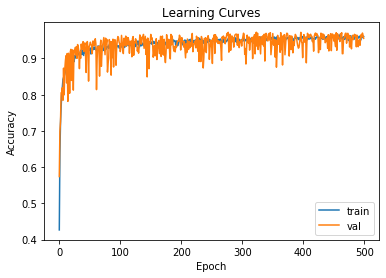

In [20]:
# plot learning curves
pyplot.title('Learning Curves')
pyplot.xlabel('Epoch')
pyplot.ylabel('Accuracy')
# pyplot.plot(history.history['loss'], label='train')
# pyplot.plot(history.history['val_loss'], label='val')
pyplot.plot(history.history['accuracy'], label='train')
pyplot.plot(history.history['val_accuracy'], label='val')
pyplot.legend()
pyplot.show()

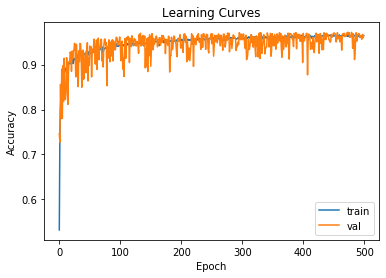

In [24]:
# plot learning curves
pyplot.title('Learning Curves')
pyplot.xlabel('Epoch')
pyplot.ylabel('Accuracy')
# pyplot.plot(history.history['loss'], label='train')
# pyplot.plot(history.history['val_loss'], label='val')
pyplot.plot(history.history['accuracy'], label='train')
pyplot.plot(history.history['val_accuracy'], label='val')
pyplot.legend()
pyplot.show()

### Grid Search

In [8]:
#Shouls chage
import numpy
from keras.models import Sequential
from keras.layers import Dropout
from keras.layers import Dense
from keras.optimizers import Adam
from keras.layers import BatchNormalization
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from keras.wrappers.scikit_learn import KerasClassifier

In [9]:
def create_model(hidden_layers=3,neurons=128,optimizer='adam',learn_rate=0.001, init_mode='he_normal', activation='relu', dropout_rate=0.0, weight_constraint=0):#parameters here are default
    #create model
    model = tf.keras.models.Sequential()
    #los weight_initializer son mas optimos dependiendo de la funcion de activacion
    
    for i in range(hidden_layers):
        model.add(tf.keras.layers.Dense(neurons, kernel_initializer=init_mode, activation=activation))
        #     model.add(BatchNormalization())     , use_bias=False
        #     model.add(tf.keras.layers.Dropout(dropout_rate))
    
    model.add(tf.keras.layers.Dense(5, activation='softmax'))
    
    #aqui estoy obligando a que el optimizer sea adam. Deberia decir: if optimizer=='adam' then... y hacerlo para otros optimizadores
    #optimizer = tf.keras.optimizers.Adam(learning_rate=learn_rate, beta_1=0.9, beta_2=0.999, amsgrad=False)
    #compile model        https://keras.io/models/model/
    model.compile(optimizer=optimizer,loss='sparse_categorical_crossentropy',metrics=['accuracy'])
    return model

# fix random seed for reproducibility
seed = 7
numpy.random.seed(seed)


In [10]:
history=model.fit(X_train, y_train_np, epochs=5, batch_size=128, validation_data=(X_test, y_test))

Train on 31493 samples, validate on 10498 samples
Epoch 1/5
31493/31493 [==============================] - 1s 43us/sample - loss: 1.1172 - accuracy: 0.5438 - val_loss: 0.8206 - val_accuracy: 0.6878
Epoch 2/5
31493/31493 [==============================] - 1s 19us/sample - loss: 0.7179 - accuracy: 0.7442 - val_loss: 0.7060 - val_accuracy: 0.6987
Epoch 3/5
31493/31493 [==============================] - 1s 17us/sample - loss: 0.5983 - accuracy: 0.7724 - val_loss: 0.6925 - val_accuracy: 0.6959
Epoch 4/5
31493/31493 [==============================] - 1s 19us/sample - loss: 0.4978 - accuracy: 0.8263 - val_loss: 0.4609 - val_accuracy: 0.8626
Epoch 5/5
31493/31493 [==============================] - 1s 28us/sample - loss: 0.4503 - accuracy: 0.8319 - val_loss: 0.4211 - val_accuracy: 0.8294


In [15]:
model = KerasClassifier(build_fn=create_model, epochs=25, batch_size=64, verbose=1) #if I add any param here has to be in the model(there has to be a default value)#de values that I set here are definitive

In [16]:
# PARAMETERS  SI QUIERO CUALQUIER PARAMETRO QUE NO SEA EL DEFAULT LO PONGO AQUI ABAJO
batch_size = [128]#[128,264]
epochs = [500]
optimizer = ['Adam']#['Nadam','Adagrad','SGD', 'RMSprop', 'Adagrad', 'Adadelta',  'Adamax', 'Nadam']
learn_rate = [0.01,0.001,0.0001]#[0.001, 0.01, 0.1, 0.2, 0.3]
momentum = [0]#[0.0, 0.2, 0.4, 0.6, 0.8, 0.9]  #en este caso momentum es para SGD por ej., para adam solo se usa learn. rate
activation = ['relu']#['softmax', 'softplus', 'softsign', 'relu', 'tanh', 'sigmoid', 'hard_sigmoid', 'linear']
init_mode = ['glorot_uniform','glorot_normal' ,'lecun_uniform']#['uniform', 'lecun_uniform', 'normal', 'zero', 'glorot_normal', 'glorot_uniform', 'he_normal', 'he_uniform']
weight_constraint = [0]#[1, 2, 3, 4, 5]
dropout_rate =[0,0.1,0.2] #[0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
neurons = [150,2300] #[5, 10, 15, 20, 25, 30]
hidden_layers= [5,25,100]

param_grid = dict(epochs=epochs, optimizer=optimizer, init_mode=init_mode, neurons=neurons, hidden_layers=hidden_layers)


In [ ]:
%%time
#FIT GRID SEARCH
grid = GridSearchCV(estimator=model, param_grid=param_grid, n_jobs=-1, cv=5, verbose=1)
#FIT RANDOM GRID SEARCH
#grid = RandomizedSearchCV(estimator=model, param_distributions=param_grid, n_jobs=-1, cv=2)
grid_result = grid.fit(X_train, y_train_np)

Fitting 5 folds for each of 18 candidates, totalling 90 fits


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.


In [ ]:
# summarize results

print("Best: %f using %s" % (grid_result.best_score_, grid_result.best_params_))
# means = grid_result.cv_results_['mean_test_score']
# stds = grid_result.cv_results_['std_test_score']
# params = grid_result.cv_results_['params']
# for mean, stdev, param in zip(means, stds, params):
#     print("%f (%f) with: %r" % (mean, stdev, param))

In [10]:
results = pd.DataFrame(grid_result.cv_results_)
results.to_csv('random-grid-search-results-03.csv', index=False)

In [11]:
results

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_epochs,param_hidden_layers,param_init_mode,param_neurons,param_optimizer,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,1109.592887,290.070685,0.802189,0.270133,500,3,he_uniform,20,Adam,"{'epochs': 500, 'hidden_layers': 3, 'init_mode...",0.965074,0.962375,0.959835,0.912829,0.958082,0.951639,0.019548,12
1,561.664953,23.897963,1.021259,0.150457,500,3,he_uniform,50,Adam,"{'epochs': 500, 'hidden_layers': 3, 'init_mode...",0.972377,0.969201,0.966344,0.965703,0.967768,0.968279,0.002378,2
2,655.796698,37.961556,1.177274,0.219627,500,3,he_uniform,100,Adam,"{'epochs': 500, 'hidden_layers': 3, 'init_mode...",0.912526,0.966661,0.967931,0.967768,0.969990,0.956975,0.022251,7
3,960.244581,36.629968,1.261204,0.289866,500,3,he_uniform,150,Adam,"{'epochs': 500, 'hidden_layers': 3, 'init_mode...",0.962216,0.971900,0.936974,0.964909,0.950619,0.957324,0.012272,6
4,560.450812,10.908165,1.001961,0.084071,500,5,he_uniform,20,Adam,"{'epochs': 500, 'hidden_layers': 5, 'init_mode...",0.967138,0.940943,0.941896,0.967609,0.965068,0.956531,0.012372,9
5,706.382032,41.763330,1.068717,0.166672,500,5,he_uniform,50,Adam,"{'epochs': 500, 'hidden_layers': 5, 'init_mode...",0.961105,0.961105,0.969360,0.922198,0.969990,0.956752,0.017698,8
6,867.139716,47.199211,1.573992,0.158567,500,5,he_uniform,100,Adam,"{'epochs': 500, 'hidden_layers': 5, 'init_mode...",0.965074,0.966661,0.969360,0.971737,0.958717,0.966310,0.004429,3
7,1376.488315,71.903676,1.576278,0.337862,500,5,he_uniform,150,Adam,"{'epochs': 500, 'hidden_layers': 5, 'init_mode...",0.970154,0.969836,0.971583,0.971896,0.968244,0.970343,0.001315,1
8,811.482436,18.104846,1.449373,0.081629,500,10,he_uniform,20,Adam,"{'epochs': 500, 'hidden_layers': 10, 'init_mod...",0.936974,0.929830,0.968249,0.960622,0.942998,0.947735,0.014462,14
9,940.923867,61.930587,1.665412,0.195899,500,10,he_uniform,50,Adam,"{'epochs': 500, 'hidden_layers': 10, 'init_mod...",0.968725,0.927290,0.966503,0.946015,0.913147,0.944336,0.021690,15


In [12]:
import pandas as pd
import csv
results = pd.read_csv('random-grid-search-results-02.csv', delimiter=',')


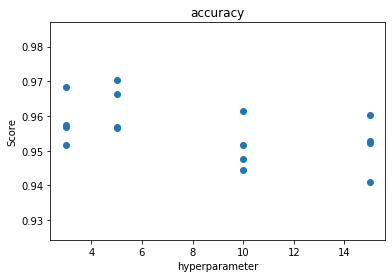

In [13]:
# plot learning curves
pyplot.title('accuracy')
pyplot.xlabel('hyperparameter')
pyplot.ylabel('Score')
pyplot.scatter(results['param_hidden_layers'],results['mean_test_score'] )
pyplot.show()